# We conducted the XGBoost to project the daily runoff with 'pre', 'tm', 'mb' in Xiehela

In [49]:
import numpy as np

def nse(observed, predicted):
    """Calculate Nash-Sutcliffe Efficiency (NSE)"""
    observed_mean = np.mean(observed)
    numerator = np.sum((observed - predicted) ** 2)
    denominator = np.sum((observed - observed_mean) ** 2)
    nse_value = 1 - (numerator / denominator)
    return nse_value

In [50]:
import pandas as pd
import os

os.chdir('F:\\geodata\\river_runoff_obs')
# Load the dataset
file_path = '3_xhl_imputMF_future.csv'  # Update the path as needed
data = pd.read_csv(file_path)
data = data[['time','pre', 'tm', 'tmax','tmin','dis']]
data['time'] = pd.to_datetime(data['time'], format='%Y/%m/%d', errors='coerce')
data = data[data['time'].dt.year >=2000]
# Check the structure of the data
print(data.head())
print(data.info())


            time       pre        tm      tmax       tmin   dis
13879 2000-01-01  0.014012 -7.989127 -0.986045 -12.293592  22.6
13880 2000-01-02  0.010840 -7.681001  1.255802 -14.322050  22.6
13881 2000-01-03  0.018878 -5.530539  3.503035 -12.432997  22.9
13882 2000-01-04  0.042975 -7.195954 -0.787331 -12.822931  23.3
13883 2000-01-05  0.037829 -9.279266 -3.451714 -14.217329  23.0
<class 'pandas.core.frame.DataFrame'>
Index: 36890 entries, 13879 to 50768
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    36890 non-null  datetime64[ns]
 1   pre     36890 non-null  float64       
 2   tm      36890 non-null  float64       
 3   tmax    36890 non-null  float64       
 4   tmin    36890 non-null  float64       
 5   dis     7222 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 2.0 MB
None


In [51]:
# Example of adding a 1-month lag
data['pre_lag1'] = data['pre'].shift(1)
data['tm_lag1'] = data['tm'].shift(1)
data['tmax_lag1'] = data['tmax'].shift(1)
data['tmin_lag1'] = data['tmin'].shift(1)


# Drop rows with NaN values resulting from shifting
data = data.dropna()

# Select input features and target
X = data[['pre', 'tm', 'tmax','tmin', 'pre_lag1', 'tm_lag1', 'tmax_lag1', 'tmin_lag1']]
y = data['dis']


In [52]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"RMSE: {rmse}")


RMSE: 89.62520549964577


D:\Users\HP\miniconda3\envs\gpd_env\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [53]:
X_train

,pre,tm,tmax,tmin,pre_lag1,tm_lag1,tmax_lag1,tmin_lag1
14791,0.457898,20.026846,26.812119,11.765785,0.000000,20.636574,25.827179,15.260794
20418,0.119062,-5.597518,1.812438,-10.267800,0.030122,-6.117488,0.230080,-10.469643
15795,0.219207,7.405271,14.088535,-0.578257,0.000000,5.702639,13.023784,-2.171747
17238,0.017464,-1.056187,5.615688,-6.661132,0.015279,-2.254070,4.297327,-7.727615
21064,2.071667,15.640903,21.933727,10.296772,3.110542,14.942918,22.671670,11.600403
...,...,...,...,...,...,...,...,...
17652,0.086902,15.478114,24.516254,6.884293,0.233042,14.219194,22.387215,5.850792
19071,0.080040,5.086262,9.995300,0.277322,0.382994,5.560668,10.301291,0.494171
19106,0.351732,6.910983,10.988241,4.017114,0.315011,12.347669,16.344368,8.226004
19270,0.219248,12.114148,19.158121,6.618488,0.115325,11.856170,18.591728,6.210805


In [54]:
nse_value = nse(y_test, y_pred)
print(f"NSE: {nse_value}")

NSE: 0.7736630001441444


In [55]:
data 

,time,pre,tm,tmax,tmin,dis,pre_lag1,tm_lag1,tmax_lag1,tmin_lag1
13880,2000-01-02,0.010840,-7.681001,1.255802,-14.322050,22.6,0.014012,-7.989127,-0.986045,-12.293592
13881,2000-01-03,0.018878,-5.530539,3.503035,-12.432997,22.9,0.010840,-7.681001,1.255802,-14.322050
13882,2000-01-04,0.042975,-7.195954,-0.787331,-12.822931,23.3,0.018878,-5.530539,3.503035,-12.432997
13883,2000-01-05,0.037829,-9.279266,-3.451714,-14.217329,23.0,0.042975,-7.195954,-0.787331,-12.822931
13884,2000-01-06,0.036510,-9.179513,-2.782381,-14.326047,23.0,0.037829,-9.279266,-3.451714,-14.217329
...,...,...,...,...,...,...,...,...,...,...
21096,2019-10-05,0.109306,10.953600,15.455995,7.675427,105.0,0.861162,9.542356,12.367226,6.329429
21097,2019-10-06,0.084878,11.619114,15.944982,8.265287,102.0,0.109306,10.953600,15.455995,7.675427
21098,2019-10-07,0.213279,10.158779,15.548484,5.975838,103.0,0.084878,11.619114,15.944982,8.265287
21099,2019-10-08,0.187744,10.165917,17.563244,4.747796,101.0,0.213279,10.158779,15.548484,5.975838


In [56]:
data = pd.read_csv(file_path)
data = data[['time','pre', 'tm', 'tmax','tmin','dis']]
data['time'] = pd.to_datetime(data['time'], format='%Y/%m/%d', errors='coerce')
data = data[data['time'].dt.year >=2000]# Example of adding a 1-month lag
# data = data[data['dis'].isna()] 
data['pre_lag1'] = data['pre'].shift(1)
data['tm_lag1'] = data['tm'].shift(1)
data['tmax_lag1'] = data['tmax'].shift(1)
data['tmin_lag1'] = data['tmin'].shift(1)
future_data = data[data['dis'].isna()] 
# Prepare future data inputs for the model (remove 'dis' column if it exists)
X_future = future_data[['pre', 'tm', 'tmax','tmax', 'pre_lag1', 'tm_lag1', 'tmax_lag1', 'tmin_lag1']]
future_data

,time,pre,tm,tmax,tmin,dis,pre_lag1,tm_lag1,tmax_lag1,tmin_lag1
21101,2019-10-10,8.011853e-01,8.487637,14.684820,4.054260,NaN,9.249459e-02,9.148915,15.269130,4.835611
21102,2019-10-11,1.242502e-02,7.162038,14.905292,0.559312,NaN,8.011853e-01,8.487637,14.684820,4.054260
21103,2019-10-12,3.359187e-01,7.573530,13.056841,3.067927,NaN,1.242502e-02,7.162038,14.905292,0.559312
21104,2019-10-13,3.397034e+00,6.029230,9.795455,2.312952,NaN,3.359187e-01,7.573530,13.056841,3.067927
21105,2019-10-14,7.476496e-02,6.474875,12.850509,0.523805,NaN,3.397034e+00,6.029230,9.795455,2.312952
...,...,...,...,...,...,...,...,...,...,...
50764,2100-12-27,1.790000e-05,-0.841248,0.803955,-3.533447,NaN,1.940000e-05,-0.533722,0.096161,-1.085938
50765,2100-12-28,1.710000e-07,-2.486938,-1.406189,-3.865570,NaN,1.790000e-05,-0.841248,0.803955,-3.533447
50766,2100-12-29,1.410000e-07,-3.094513,-1.394623,-4.438141,NaN,1.710000e-07,-2.486938,-1.406189,-3.865570
50767,2100-12-30,6.680000e-23,-3.621063,-1.390442,-6.525024,NaN,1.410000e-07,-3.094513,-1.394623,-4.438141


In [57]:
X_future

,pre,tm,tmax,tmax,pre_lag1,tm_lag1,tmax_lag1,tmin_lag1
21101,8.011853e-01,8.487637,14.684820,14.684820,9.249459e-02,9.148915,15.269130,4.835611
21102,1.242502e-02,7.162038,14.905292,14.905292,8.011853e-01,8.487637,14.684820,4.054260
21103,3.359187e-01,7.573530,13.056841,13.056841,1.242502e-02,7.162038,14.905292,0.559312
21104,3.397034e+00,6.029230,9.795455,9.795455,3.359187e-01,7.573530,13.056841,3.067927
21105,7.476496e-02,6.474875,12.850509,12.850509,3.397034e+00,6.029230,9.795455,2.312952
...,...,...,...,...,...,...,...,...
50764,1.790000e-05,-0.841248,0.803955,0.803955,1.940000e-05,-0.533722,0.096161,-1.085938
50765,1.710000e-07,-2.486938,-1.406189,-1.406189,1.790000e-05,-0.841248,0.803955,-3.533447
50766,1.410000e-07,-3.094513,-1.394623,-1.394623,1.710000e-07,-2.486938,-1.406189,-3.865570
50767,6.680000e-23,-3.621063,-1.390442,-1.390442,1.410000e-07,-3.094513,-1.394623,-4.438141


In [58]:
# Predict runoff for future periods
future_data['runoff_projection'] = model.predict(X_future.to_numpy())
print(future_data[['time', 'runoff_projection']])  # Display future projections

            time  runoff_projection
21101 2019-10-10         133.115204
21102 2019-10-11         134.387772
21103 2019-10-12         269.291168
21104 2019-10-13         297.322784
21105 2019-10-14         290.486969
...          ...                ...
50764 2100-12-27          44.903446
50765 2100-12-28          44.903446
50766 2100-12-29          44.903446
50767 2100-12-30          44.903446
50768 2100-12-31          42.286884

[29668 rows x 2 columns]


C:\Users\HP\AppData\Local\Temp\ipykernel_43260\2318858548.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  future_data['runoff_projection'] = model.predict(X_future.to_numpy())


In [59]:
# Concatenate historical and future data
historic_data = data.dropna()
combined_data = pd.concat([historic_data, future_data])
# Convert the 'time' column to datetime format, matching the format of your data
combined_data['time'] = pd.to_datetime(combined_data['time'], format='%Y/%m/%d', errors='coerce')

# Drop any rows where 'time' couldn't be parsed (if there are invalid dates)
combined_data = combined_data.dropna(subset=['time'])

# Set 'time' as the index
combined_data.set_index('time', inplace=True)

# Display the updated DataFrame with 'time' as the index
print(combined_data.head())


                 pre        tm      tmax       tmin   dis  pre_lag1   tm_lag1  \
time                                                                            
2000-01-02  0.010840 -7.681001  1.255802 -14.322050  22.6  0.014012 -7.989127   
2000-01-03  0.018878 -5.530539  3.503035 -12.432997  22.9  0.010840 -7.681001   
2000-01-04  0.042975 -7.195954 -0.787331 -12.822931  23.3  0.018878 -5.530539   
2000-01-05  0.037829 -9.279266 -3.451714 -14.217329  23.0  0.042975 -7.195954   
2000-01-06  0.036510 -9.179513 -2.782381 -14.326047  23.0  0.037829 -9.279266   

            tmax_lag1  tmin_lag1  runoff_projection  
time                                                 
2000-01-02  -0.986045 -12.293592                NaN  
2000-01-03   1.255802 -14.322050                NaN  
2000-01-04   3.503035 -12.432997                NaN  
2000-01-05  -0.787331 -12.822931                NaN  
2000-01-06  -3.451714 -14.217329                NaN  


<Axes: xlabel='time'>

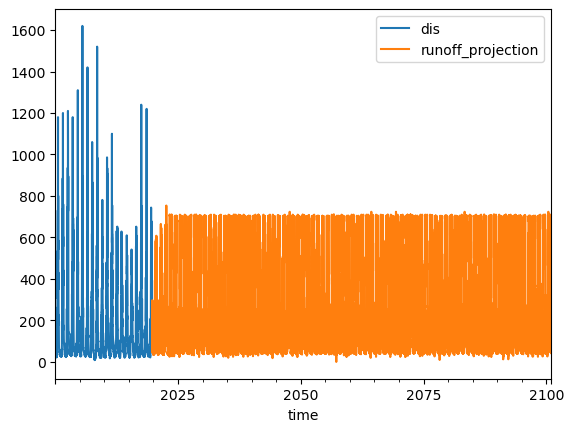

In [60]:
combined_data[['dis','runoff_projection']].plot()